In [213]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [215]:
df = pd.read_csv("credit_risk_dataset.csv")

In [216]:
print(df.head())
df.shape

   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                           3  


(32581, 12)

In [217]:
columns=df.columns.tolist()

# Missing values

In [221]:
(df.isnull().sum()/df.shape[0]) *100

person_age                    0.000000
person_income                 0.000000
person_home_ownership         0.000000
person_emp_length             2.747000
loan_intent                   0.000000
loan_grade                    0.000000
loan_amnt                     0.000000
loan_int_rate                 9.563856
loan_status                   0.000000
loan_percent_income           0.000000
cb_person_default_on_file     0.000000
cb_person_cred_hist_length    0.000000
dtype: float64

In [223]:
df['loan_status'].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

In [225]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [227]:
df[df['person_emp_length'].isnull()]['loan_status'].value_counts(normalize=True)

loan_status
0    0.684916
1    0.315084
Name: proportion, dtype: float64

In [229]:
(df['loan_status'].value_counts()/len(df))*100

loan_status
0    78.183604
1    21.816396
Name: count, dtype: float64

# handling the missing values

In [233]:
df['emp_length_missing']=df['person_emp_length'].isnull().astype(int)

In [235]:
df.shape

(32581, 13)

In [237]:
df['person_emp_length'].fillna(df['person_emp_length'].median(),inplace=True)

C:\Users\BHUVAN\AppData\Local\Temp\ipykernel_12688\258519556.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['person_emp_length'].fillna(df['person_emp_length'].median(),inplace=True)


In [238]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length                0
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
emp_length_missing               0
dtype: int64

In [239]:
df[df['loan_int_rate'].isnull()]['loan_status'].value_counts(normalize=True)

loan_status
0    0.793325
1    0.206675
Name: proportion, dtype: float64

In [243]:
print(df.groupby(df['loan_int_rate'].isnull())['person_income'].mean())
df.groupby(df['loan_int_rate'].isnull())['loan_amnt'].mean()

loan_int_rate
False    66020.47049
True     66589.04846
Name: person_income, dtype: float64


loan_int_rate
False    9584.744612
True     9633.119384
Name: loan_amnt, dtype: float64

In [245]:
df['loan_int_rate'].fillna(df['loan_int_rate'].median(),inplace=True)

C:\Users\BHUVAN\AppData\Local\Temp\ipykernel_12688\1722227870.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['loan_int_rate'].fillna(df['loan_int_rate'].median(),inplace=True)


In [247]:
df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
emp_length_missing            0
dtype: int64

In [249]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,emp_length_missing
count,32581.000000,3.258100e+04,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.767994,9589.371106,11.009620,0.218164,0.170203,5.804211,0.027470
std,6.348078,6.198312e+04,4.087372,6322.086646,3.081611,0.413006,0.106782,4.055001,0.163451
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000,0.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,8.490000,0.000000,0.090000,3.000000,0.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000,0.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.110000,0.000000,0.230000,8.000000,0.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000,1.000000


# handling Outliers

In [252]:
df['person_age'].quantile(0.99)

50.0

In [254]:
df=df[df['person_age']<=70]

In [256]:
len(df)

32568

In [258]:
df['person_emp_length'].quantile(0.9999)

33.229899999994814

In [260]:
df=df[df['person_emp_length']<=40]

In [262]:
len(df)

32566

In [264]:
df['person_income'].quantile([0.90,0.95,0.99,0.999])

0.900    110004.0
0.950    138000.0
0.990    225000.0
0.999    641220.0
Name: person_income, dtype: float64

In [266]:
df=df[df['person_income']<=225000]

In [268]:
len(df)

32242

In [270]:
df['loan_amnt'].quantile([0.90,0.95,0.99,0.999])

0.900    18400.0
0.950    22800.0
0.990    28000.0
0.999    35000.0
Name: loan_amnt, dtype: float64

# Bivariate Analysis

In [273]:
df.groupby('loan_status')['loan_percent_income'].mean()

loan_status
0    0.149873
1    0.247852
Name: loan_percent_income, dtype: float64

In [275]:
df.groupby('loan_status')['person_income'].mean()

loan_status
0    66967.922741
1    47505.496958
Name: person_income, dtype: float64

In [277]:
df.groupby('loan_status')['loan_amnt'].mean()

loan_status
0     9148.036743
1    10788.683317
Name: loan_amnt, dtype: float64

In [279]:
df.groupby('loan_status')['loan_int_rate'].mean()

loan_status
0    10.479576
1    12.860884
Name: loan_int_rate, dtype: float64

In [281]:
df.groupby('loan_grade')['loan_status'].mean()

loan_grade
A    0.100253
B    0.163847
C    0.209364
D    0.594065
E    0.646251
F    0.707627
G    0.984127
Name: loan_status, dtype: float64

### dropping the loan_grade column because it is predicted by the bank and sometimes may not be available while prediction time


In [284]:
df=df.drop(columns=['loan_grade'])

In [286]:
df=df.drop(columns=['loan_int_rate'])

In [288]:
df.shape

(32242, 11)

In [289]:
df.groupby('cb_person_default_on_file')['loan_status'].mean()

cb_person_default_on_file
N    0.184955
Y    0.379675
Name: loan_status, dtype: float64

In [292]:
df.groupby('loan_status')['cb_person_cred_hist_length'].mean()

loan_status
0    5.793724
1    5.669025
Name: cb_person_cred_hist_length, dtype: float64

In [294]:
df.groupby('person_home_ownership')['loan_status'].mean()

person_home_ownership
MORTGAGE    0.125833
OTHER       0.317308
OWN         0.075088
RENT        0.316375
Name: loan_status, dtype: float64

In [296]:
df['person_home_ownership'].value_counts()

person_home_ownership
RENT        16373
MORTGAGE    13208
OWN          2557
OTHER         104
Name: count, dtype: int64

In [298]:
df.groupby('loan_intent')['loan_status'].mean().sort_values()

loan_intent
VENTURE              0.149214
EDUCATION            0.172780
PERSONAL             0.200476
HOMEIMPROVEMENT      0.263498
MEDICAL              0.267488
DEBTCONSOLIDATION    0.286712
Name: loan_status, dtype: float64

In [300]:
df.corr(numeric_only=True)['loan_status']

person_age                   -0.017663
person_income                -0.234512
person_emp_length            -0.085936
loan_amnt                     0.108997
loan_status                   1.000000
loan_percent_income           0.380154
cb_person_cred_hist_length   -0.012832
emp_length_missing            0.039655
Name: loan_status, dtype: float64

In [301]:
df.corr(numeric_only=True)

,person_age,person_income,person_emp_length,loan_amnt,loan_status,loan_percent_income,cb_person_cred_hist_length,emp_length_missing
person_age,1.000000,0.101587,0.166737,0.044910,-0.017663,-0.031811,0.877829,-0.010489
person_income,0.101587,1.000000,0.189851,0.400829,-0.234512,-0.345003,0.079401,-0.098183
person_emp_length,0.166737,0.189851,1.000000,0.107907,-0.085936,-0.053610,0.143124,-0.031456
loan_amnt,0.044910,0.400829,0.107907,1.000000,0.108997,0.596877,0.034918,-0.066635
loan_status,-0.017663,-0.234512,-0.085936,0.108997,1.000000,0.380154,-0.012832,0.039655
loan_percent_income,-0.031811,-0.345003,-0.053610,0.596877,0.380154,1.000000,-0.021980,0.032506
cb_person_cred_hist_length,0.877829,0.079401,0.143124,0.034918,-0.012832,-0.021980,1.000000,-0.006535
emp_length_missing,-0.010489,-0.098183,-0.031456,-0.066635,0.039655,0.032506,-0.006535,1.000000


# feature selection

In [303]:
df=df.drop(columns=['cb_person_cred_hist_length'])

In [304]:
df.shape

(32242, 10)

# train test split

In [310]:
from sklearn.model_selection import train_test_split

In [312]:
x=df.drop(columns=['loan_status'])
y=df['loan_status']

In [314]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=33)

In [316]:
y_train.value_counts(normalize=True)

loan_status
0    0.780832
1    0.219168
Name: proportion, dtype: float64

In [318]:
y_train.value_counts(normalize=True)

loan_status
0    0.780832
1    0.219168
Name: proportion, dtype: float64

# encoding 

In [321]:
cac=[col for col in x.columns if df[col].dtype=='object']
cac

['person_home_ownership', 'loan_intent', 'cb_person_default_on_file']

In [323]:
from sklearn.preprocessing import OneHotEncoder

In [325]:
encoder=OneHotEncoder(drop='first',sparse_output=False)
encoder.fit(x_train[cac])


OneHotEncoder(drop='first', sparse_output=False)

In [327]:
x_e_tr=encoder.transform(x_train[cac])
x_e_te=encoder.transform(x_test[cac])

In [329]:
encoded_cols = encoder.get_feature_names_out(cac)
encoded_cols

array(['person_home_ownership_OTHER', 'person_home_ownership_OWN',
       'person_home_ownership_RENT', 'loan_intent_EDUCATION',
       'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL',
       'loan_intent_PERSONAL', 'loan_intent_VENTURE',
       'cb_person_default_on_file_Y'], dtype=object)

In [331]:
x_tr_num = x_train.drop(columns=cac)
x_te_num = x_test.drop(columns=cac)

In [333]:
x_tr = pd.concat(
    [x_tr_num.reset_index(drop=True),
     pd.DataFrame(x_e_tr, columns=encoded_cols)],
    axis=1
)
x_te= pd.concat(
    [x_te_num.reset_index(drop=True),
     pd.DataFrame(x_e_te, columns=encoded_cols)],
    axis=1
)

In [335]:
x_tr.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_percent_income,emp_length_missing,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,cb_person_default_on_file_Y
0,30,14400,0.0,5000,0.35,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,26,58000,10.0,5000,0.09,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,22,36000,6.0,14500,0.40,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,25,132000,1.0,12000,0.09,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,25,40000,6.0,5000,0.13,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [337]:
x_te.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_percent_income,emp_length_missing,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,cb_person_default_on_file_Y
0,23,85000,2.0,12000,0.14,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
1,34,25480,6.0,5000,0.20,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,25,107000,0.0,7000,0.07,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,21,35000,0.0,3500,0.10,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,25,84000,7.0,6500,0.08,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


# scaling

In [340]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

In [342]:
nc=[col for col in df.columns if df[col].dtype!='object']
nc.remove('loan_status')
nc

['person_age',
 'person_income',
 'person_emp_length',
 'loan_amnt',
 'loan_percent_income',
 'emp_length_missing']

In [344]:
x_tr[nc]=sc.fit_transform(x_tr[nc])
x_te[nc]=sc.fit_transform(x_te[nc])

In [346]:
x_tr.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_percent_income,emp_length_missing,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,cb_person_default_on_file_Y
0,0.383511,-1.407414,-1.197486,-0.723390,1.683198,-0.166899,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,-0.270531,-0.137974,1.329947,-0.723390,-0.762495,-0.166899,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-0.924573,-0.778517,0.318974,0.804436,2.153523,-0.166899,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,-0.434042,2.016580,-0.944742,0.402377,-0.762495,-0.166899,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.434042,-0.662055,0.318974,-0.723390,-0.386235,-0.166899,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [348]:
x_te.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_percent_income,emp_length_missing,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,cb_person_default_on_file_Y
0,-0.758695,0.654733,-0.692726,0.391810,-0.301313,-0.175173,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
1,1.036537,-1.081481,0.318911,-0.725871,0.254938,-0.175173,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,-0.432289,1.296478,-1.198544,-0.406533,-0.950273,-0.175173,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,-1.085100,-0.803780,-1.198544,-0.965374,-0.672147,-0.175173,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,-0.432289,0.625562,0.571820,-0.486368,-0.857564,-0.175173,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


# training of logistic regression model

In [351]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(class_weight='balanced',max_iter=1000,random_state=33)


In [353]:
lr.fit(x_tr,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=33)

In [354]:
y_pr=lr.predict(x_te)

In [357]:
y_pr[:10]

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int64)

# evaluation of logistic regression model

In [360]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pr)
cm

array([[3796, 1239],
       [ 377, 1037]], dtype=int64)

In [386]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, lr.predict_proba(x_te)[:,1])

0.8189125906490494

In [388]:
threshold = 0.4
lr_proba=lr.predict_proba(x_te)[:,1]
y_pred_04 = (y_proba >= threshold).astype(int)

In [390]:
confusion_matrix(y_test, y_pred_04)

array([[3193, 1842],
       [ 261, 1153]], dtype=int64)

In [392]:
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score,roc_auc_score
roc_auc_score(y_test, lr_proba)

0.8189125906490494

In [394]:
print(f'accuracy :{accuracy_score(y_test,y_pred_04)*100:.2f}')
print(f'recall :{recall_score(y_test,y_pred_04)*100:.2f}')
print(f'Precision :{precision_score(y_test,y_pred_04)*100:.2f}')
print(f'f1-score :{f1_score(y_test,y_pred_04)*100:.2f}')
print(f'roc-auc score :{roc_auc_score(y_test,lr_proba)*100:.2f}')

accuracy :67.39
recall :81.54
Precision :38.50
f1-score :52.30
roc-auc score :81.89


# cross validation on logistic regression model

In [397]:
from sklearn.model_selection import cross_val_score

In [399]:
lr_scores = cross_val_score(
    lr,
    x_tr,
    y_train,
    cv=5,
    scoring='roc_auc'
)

In [401]:
print(lr_scores)
print("Average ROC:", lr_scores.mean())

[0.81412495 0.80381011 0.81085847 0.80912704 0.80017686]
Average ROC: 0.8076194874651179


# training on random forest model

In [404]:
from sklearn.ensemble import RandomForestClassifier

In [406]:
rfc=RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    max_features='sqrt',
    random_state=33)

In [408]:
rfc.fit(x_tr,y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=33)

In [409]:
rfc_pr=rfc.predict(x_te)
rfc_proba=rfc.predict_proba(x_te)[:,1]

# evaluation of random forest model

In [413]:
cmr=confusion_matrix(y_test,rfc_pr)
cmr

array([[4956,   79],
       [ 657,  757]], dtype=int64)

In [415]:
print(f'accuracy :{accuracy_score(y_test,rfc_pr)*100:.2f}')
print(f'recall :{recall_score(y_test,rfc_pr)*100:.2f}')
print(f'Precision :{precision_score(y_test,rfc_pr)*100:.2f}')
print(f'f1-score :{f1_score(y_test,rfc_pr)*100:.2f}')
print(f'roc-auc score :{roc_auc_score(y_test,rfc_proba)*100:.2f}')

accuracy :88.59
recall :53.54
Precision :90.55
f1-score :67.29
roc-auc score :88.33


In [417]:
feature_importance = pd.Series(
    rfc.feature_importances_,
    index=x_tr.columns
).sort_values(ascending=False)

feature_importance.head(10)

person_income                  0.244210
loan_percent_income            0.229710
loan_amnt                      0.142555
person_age                     0.105985
person_emp_length              0.088540
person_home_ownership_RENT     0.056747
cb_person_default_on_file_Y    0.043487
person_home_ownership_OWN      0.018318
loan_intent_VENTURE            0.015035
loan_intent_HOMEIMPROVEMENT    0.014813
dtype: float64

# cross validation

In [420]:
from sklearn.model_selection import cross_val_score

In [422]:
scores=cross_val_score(
    rfc,
    x_tr,
    y_train,
    cv=5,
    scoring='roc_auc'
)

In [423]:
print(scores)
print("Avg ROC_AUC:",scores.mean())

[0.87596144 0.86435886 0.87116489 0.87424478 0.86357588]
Avg ROC_AUC: 0.8698611681796355


# training on xgboost model

In [425]:
from xgboost import XGBClassifier

In [426]:
xgb= XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=3,
    random_state=33,
    eval_metric="logloss"
)

In [427]:
xgb.fit(x_tr,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [428]:
xgb_pred=xgb.predict(x_te)
xgb_proba=xgb.predict_proba(x_te)[:,1]

In [429]:
print(f'accuracy :{accuracy_score(y_test,xgb_pred)*100:.2f}')
print(f'recall :{recall_score(y_test,xgb_pred)*100:.2f}')
print(f'Precision :{precision_score(y_test,xgb_pred)*100:.2f}')
print(f'f1-score :{f1_score(y_test,xgb_pred)*100:.2f}')
print(f'roc-auc score :{roc_auc_score(y_test,xgb_proba)*100:.2f}')

accuracy :86.26
recall :70.72
Precision :67.93
f1-score :69.30
roc-auc score :90.09


# cross validation for xgboost

In [431]:
scores_xgb = cross_val_score(
    xgb,
    x_tr,
    y_train,
    cv=5,
    scoring='roc_auc'
)

In [432]:
print(scores_xgb)
print("Avg roc_auc:",scores_xgb.mean())

[0.90370007 0.89415844 0.9097443  0.90940331 0.89518701]
Avg roc_auc: 0.9024386276534202


In [433]:
importance = pd.Series(
    xgb.feature_importances_,
    index=x_tr.columns
).sort_values(ascending=False)

print(importance.head(10))

person_home_ownership_RENT     0.168740
cb_person_default_on_file_Y    0.158306
person_home_ownership_OWN      0.132296
loan_percent_income            0.130305
loan_intent_HOMEIMPROVEMENT    0.070172
loan_intent_VENTURE            0.065508
person_income                  0.062124
loan_intent_EDUCATION          0.041656
loan_intent_MEDICAL            0.030813
loan_intent_PERSONAL           0.030360
dtype: float32


In [434]:
feature_importance = pd.Series(
    rfc.feature_importances_,
    index=x_tr.columns
).sort_values(ascending=False)
feature_importance.head(10)

person_income                  0.244210
loan_percent_income            0.229710
loan_amnt                      0.142555
person_age                     0.105985
person_emp_length              0.088540
person_home_ownership_RENT     0.056747
cb_person_default_on_file_Y    0.043487
person_home_ownership_OWN      0.018318
loan_intent_VENTURE            0.015035
loan_intent_HOMEIMPROVEMENT    0.014813
dtype: float64

# ROC CURVE  Comparision of the three models

In [450]:
from sklearn.metrics import roc_curve

In [454]:
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_proba)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rfc_proba)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_proba)

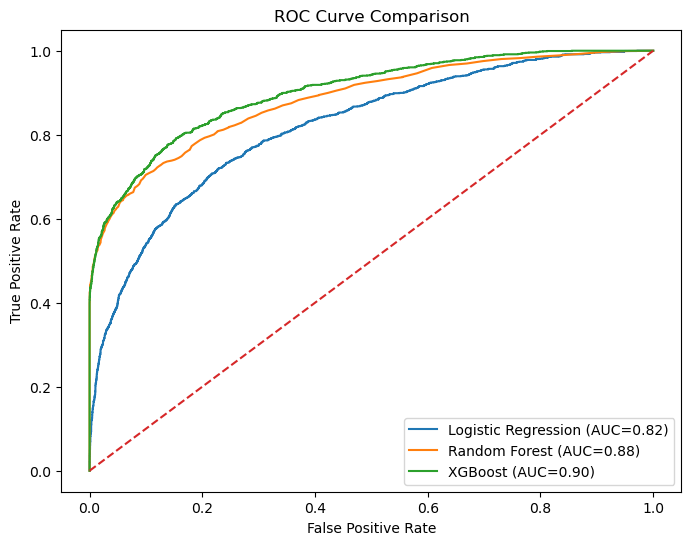

In [458]:
plt.figure(figsize=(8,6))
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC={roc_auc_score(y_test, lr_proba):.2f})')
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC={roc_auc_score(y_test, rfc_proba):.2f})')
plt.plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC={roc_auc_score(y_test, xgb_proba):.2f})')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

# Precision-Recall Curve

In [483]:
from sklearn.metrics import precision_recall_curve, average_precision_score

In [485]:
lr_precision, lr_recall, _ = precision_recall_curve(y_test, lr_proba)
rf_precision, rf_recall, _ = precision_recall_curve(y_test, rfc_proba)
xgb_precision, xgb_recall, _ = precision_recall_curve(y_test, xgb_proba)

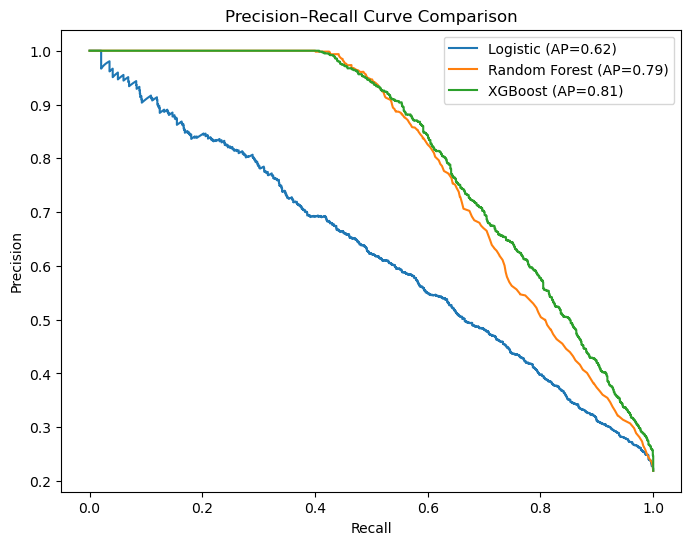

In [487]:
plt.figure(figsize=(8,6))
plt.plot(lr_recall, lr_precision,label=f"Logistic (AP={average_precision_score(y_test, lr_proba):.2f})")
plt.plot(rf_recall, rf_precision,label=f"Random Forest (AP={average_precision_score(y_test, rfc_proba):.2f})")
plt.plot(xgb_recall, xgb_precision,label=f"XGBoost (AP={average_precision_score(y_test, xgb_proba):.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve Comparison")
plt.legend()
plt.show()

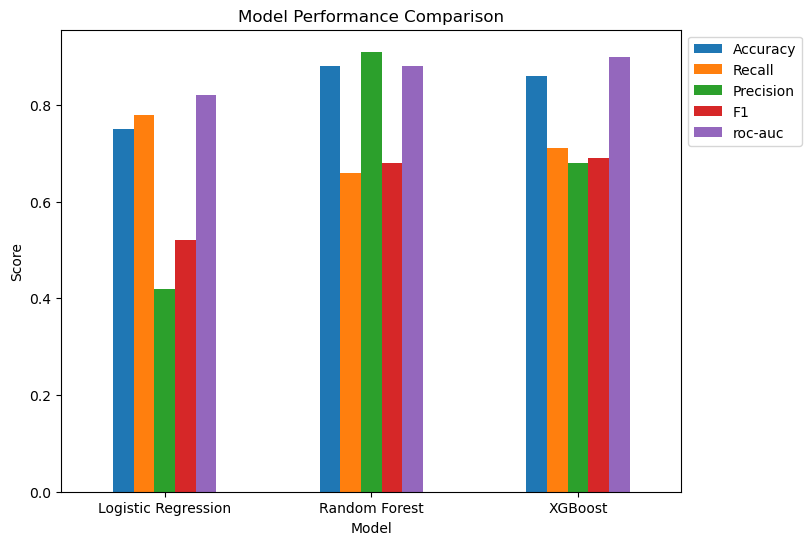

In [529]:
import pandas as pd
import matplotlib.pyplot as plt
metrics = pd.DataFrame({
    'Model': ['Logistic Regression','Random Forest','XGBoost'],
    'Accuracy':[0.75,0.88,0.86],
    'Recall':[0.78,0.66,0.71],
    'Precision':[0.42,0.91,0.68],
    'F1':[0.52,0.68,0.69],
    'roc-auc':[0.82,0.88,0.90]
})
metrics.set_index('Model').plot(kind='bar', figsize=(8,6))
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1,1), loc='upper left')
plt.show()